<a href="https://colab.research.google.com/github/tsukemono-shirumono/CircleFitting/blob/main/DeepKnowledgeTracing_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pytorch_lightning
!wget -O log_train.pkl https://www.dropbox.com/scl/fi/i35qarf2l9ag4jxue9mae/log_train.pkl?rlkey=u8m1codrfdbqocsn6ss2mn30x&st=5boafqy4&dl=0
!wget -O log_val.pkl https://www.dropbox.com/scl/fi/fmoegncojlkj8y7mwqb21/log_val.pkl?rlkey=1ojevhtflv4n140hjj0lbyjy3&st=t7z0ddfy&dl=0
!wget -O question.pkl https://www.dropbox.com/scl/fi/c7mr6wdm4mb0ehj64r2fm/question.pkl?rlkey=1njorllxaoo02sisavhx691zv&st=efufm45g&dl=0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 22.5 MB/s eta 0:00:00
--2024-09-26 18:34:14--  https://www.dropbox.com/scl/fi/i35qarf2l9ag4jxue9mae/log_train.pkl?rlkey=u8m1codrfdbqocsn6ss2mn30x
Resolving www.dropbox.com (www.dropbox.com)... 162.125.85.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.85.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucd9338c77762b54857b2c12f305.dl.dropboxusercontent.com/cd/0/inline/CbUkXUDgMlamCXSunw8SlaNJGmwCaQ7juahnUKDNxzfTGKnI_NNf7nTJjQlw3LLZ_zklEDbmNU86N9eXQQwSGUfe0vbcsTQqZLy8Li5O80JxODTFh2-eyNUJRnwkMXqH9K0/file# [following]
--2024-09-26 18:34:15--  https://ucd9338c77762b54857b2c12f305.dl.dropboxusercontent.com/cd/0/inline/CbUkXUDgMlamCXSunw8SlaNJGmwCaQ7juahnUKDNxzfTGKnI_NNf7nTJjQlw3LLZ_zklEDbmNU86N9eXQQwSGUfe0vbcsTQqZLy8Li5O80JxODTFh2-eyNUJRnwkMXqH9K0/file
Resolving ucd9338c777

# DeepKnowledgeTracing
https://arxiv.org/abs/1506.05908

* $x_t = (q_t,a_t)$
* $h_t = \mathrm{LSTM}(x_t, h_{t-1})$
* $y_t = \sigma(Wh_t+b)$
* $loss = \mathrm{BCE}(y_{t,q_{t+1}}, a_{t+1})$

In [2]:
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from tqdm.notebook import tqdm
from joblib import dump, load
tqdm.pandas()

In [3]:
batch_size = 256
embedding_dim = 200
len_max = 100
lr = 0.001

In [4]:
df_train = load('log_train.pkl')
df_val = load('log_val.pkl')
df_question = load('question.pkl')
num_question = len(df_question)

## データセット準備

In [5]:
class CustomDataset(Dataset):
    def __init__(self, dataframe, len_max):
        self.dataframe = dataframe
        self.len_max = len_max

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        upid_numbers = self.dataframe.iloc[idx]['questions']
        is_correct = self.dataframe.iloc[idx]['is_correct']

        # パディング処理
        q = upid_numbers + [0] * (self.len_max - len(upid_numbers))
        a = is_correct + [False] * (self.len_max - len(is_correct))
        mask = [True] * len(upid_numbers) + [False] * (self.len_max - len(upid_numbers))

        q = torch.tensor(q, dtype=torch.long)
        a = torch.tensor(a, dtype=torch.bool)
        mask = torch.tensor(mask, dtype=torch.bool)

        return q, a, mask

In [6]:
dataset_train = CustomDataset(df_train,len_max=100)
data_loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dataset_val = CustomDataset(df_val,len_max=100)
data_loader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# モデル準備

In [10]:
class DeepKnowledgeTracingLSTM (pl.LightningModule):
    def __init__(self, num_question, embedding_dim, lr=0.001):
        super(DeepKnowledgeTracingLSTM , self).__init__()
        self.num_question = num_question
        self.embedding_dim = embedding_dim # RNNの次元<=埋め込み次元なら何次元でも性能同じ

        self.embedding = nn.Embedding(2*num_question, embedding_dim) # 正誤判定で2倍
        self.lstm = nn.LSTM(embedding_dim, embedding_dim, batch_first=True)
        self.fc = nn.Linear(embedding_dim, num_question)
        self.sigmoid = nn.Sigmoid()
        self.loss_fn = nn.BCEWithLogitsLoss()
        self.lr = lr

    def forward(self, q, a, mask):
        x = 2 * q + a
        embed = self.embedding(x)
        lengths = mask.sum(dim=1).cpu()
        packed_input = nn.utils.rnn.pack_padded_sequence(embed, lengths, batch_first=True, enforce_sorted=False)
        packed_output, _ = self.lstm(packed_input)
        lstm_output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)
        lstm_output = lstm_output * mask.unsqueeze(-1)
        score = self.fc(lstm_output)
        return score

    def pred(self, q, a):
        q = q.to(self.device)
        a = a.to(self.device)
        mask = torch.ones_like(q)
        score = self(q, a, mask)
        prob = self.sigmoid(score)
        return prob

    def compute_loss(self, q, a, score, mask, is_mean_all=False):
        q_loss = q[:,1:] # 最初の回答結果不使用
        a_loss = a[:,1:]
        mask = mask[:,1:]
        score_loss = score[:,:-1,:] # 最後のステップの正解率不使用
        y_loss = torch.gather(score_loss, 2, q_loss.unsqueeze(-1)).squeeze(-1)
        loss = self.loss_fn(y_loss, a_loss.float())
        loss = loss*mask # mask=Falseはloss=0とする
        if is_mean_all:
            loss = loss.mean()
        else:
            loss = loss.sum() / mask.sum()
        return loss

    def training_step(self, batch, batch_idx):
        q, a, mask = batch
        score = self(q, a, mask)
        loss = self.compute_loss(q, a, score, mask)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        q, a, mask = batch
        score = self(q, a, mask)
        loss = self.compute_loss(q, a, score, mask)
        self.log('val_loss', loss)
        return {'val_loss': loss}

    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

In [11]:
early_stopping = EarlyStopping(
    monitor='val_loss',  # モニターするメトリック
    patience=3,          # 改善が見られないエポック数
    mode='min',
    verbose=True
)
checkpoint_callback = ModelCheckpoint(
    monitor='val_loss',
    dirpath='checkpoints',
    filename='{epoch:02d}-{val_loss:.2f}',
    save_top_k=1,
    mode='min'
)

In [ ]:
model = DeepKnowledgeTracingLSTM(num_question, embedding_dim, lr)
trainer = pl.Trainer(max_epochs=100, callbacks=[early_stopping, checkpoint_callback])
trainer.fit(model, train_dataloaders=data_loader_train, val_dataloaders=data_loader_val)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | embedding | Embedding         | 10.3 M | train
1 | lstm      | LSTM              | 321 K  | train
2 | fc        | Linear            | 5.2 M  | train
3 | sigmoid   | Sigmoid           | 0      | train
4 | loss_fn   | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
15.9 M    Trainable params
0         Non-trainable params
15.9 M    Total params
63.427    Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
model_path = checkpoint_callback.best_model_path
model = DeepKnoeledgeTracingRNN.load_from_checkpoint(model_path, num_question=num_question, embedding_dim=embedding_dim)
torch.save(model, "model.pt")

# 評価

In [ ]:
model = torch.load("model.pt")
model.eval()

<ipython-input-6-f87c5a7a2bf3>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("model.pt")


DeepKnoeledgeTracingRNN(
  (embedding): Embedding(51698, 200)
  (rnn): RNN(200, 200, batch_first=True)
  (fc): Linear(in_features=200, out_features=25849, bias=True)
  (sigmoid): Sigmoid()
  (loss_fn): BCEWithLogitsLoss()
)

In [ ]:
torch.cuda.empty_cache()
def pred(q,a, model=model):
    with torch.no_grad():
        q_torch = torch.tensor(q, dtype=torch.long).unsqueeze(0)
        a_torch = torch.tensor(a, dtype=torch.bool).unsqueeze(0)

        prob_mat = model.pred(q_torch,a_torch)
        q_torch = q_torch[:,1:]
        prob_mat = prob_mat[:,:-1,:]
        probs = torch.gather(prob_mat, 2, q_torch.unsqueeze(-1)).flatten()
        probs = probs.cpu().numpy()
    return probs

df_val["prob"] = [pred(q,a) for q,a in tqdm(zip(df_val["questions"], df_val["is_correct"]))]
torch.cuda.empty_cache()

0it [00:00, ?it/s]

In [ ]:
probs = []
ys = []
for prob, y in tqdm(zip(df_val["prob"], df_val["is_correct"])):
    probs.extend(prob)
    ys.extend(y[1:])
df_correct = pd.DataFrame()
df_correct["prob"] = probs
df_correct["is_correct"] = ys

0it [00:00, ?it/s]

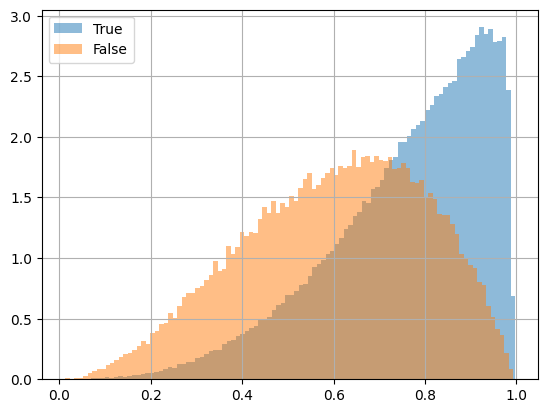

In [ ]:
df_correct[df_correct["is_correct"]]["prob"].hist(bins=100, density=True, alpha=0.5, label="True")
df_correct[~df_correct["is_correct"]]["prob"].hist(bins=100, density=True, alpha=0.5, label="False")
plt.legend()

In [ ]:
roc_auc_score(df_correct['is_correct'], df_correct['prob'])

0.7333182222408435

# ノード間のつながり取得

$$J_{ij} = \frac{Pr(j|i)}{<Pr(j|k)>_k}$$

In [ ]:
def prob_cond(i):
    with torch.no_grad():
        q = torch.tensor([i], dtype=torch.long).to(model.device)
        a = torch.tensor([True], dtype=torch.bool).to(model.device)
        probs = model.pred(q,a).flatten().cpu().numpy()
    return probs

In [ ]:
# compute_J
J = np.array([prob_cond(i) for i in tqdm(range(num_question))])
J = J/J.mean(axis=0)

  0%|          | 0/25849 [00:00<?, ?it/s]

In [ ]:
df_question_list = df_question.sample(5)

In [ ]:
df_question_list

,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
7144,6907,MIXKRps/C8qNMDjA2GpN14u+XSSHEe9G2tMTYOHB364=,hScxSa3r/rGqY02BOToHgUyoK0KVvHibLaeNeTgQjSo=,【基礎】找出等值分數 1,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,zM75Dhur9om41RTSUIivWvZ07gckl2Hi0cd3/Kx4sN4=,WtWVHkMbQgqPCU5nKx3NrjF000rro7WJRGcwCPikal4=
10197,9871,Z+5ABvI/d15HbO7WJRcrd6iideNwtKHmbeOZPqLhuyk=,pHxumVVyXnSVT3+BWEh9DrffUG1ETbtem3Ea1tiDmt4=,【基礎】多位小數的比較,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,YM8uggtD5HZBGCCzNJLU90fC9C+B8/bZP3x483rb7PI=,SNlLRBXlomLRGm/xYxZwl4AefTdtAbQiyF6bxu+sF08=
14472,14015,LTIc3hbynTBRG1OZNYj10wr2gz4dlRMOKnkyumEGMy8=,h3/qpdMuhf5rZwqcHX//oZtCPV6xOKgXZyeHSGnWAsA=,【基礎】減與除的兩步驟問題,easy,elementary,ICgke8JJv5eapCPwyj1aco8PEtoBkUbTZYIqxmYtqBk=,4cISKCt3nXWe4r6Q8bzjOiL2EYYsZyT6Z0mNNJckqEc=,5IoPxwjdrLU8uqRpL1O93XHYQ3UDaj4xuPhV7bmx1ac=
5324,5147,PQilouD2udfz3jU8PjlDvUUoHhZBgaWNDvIZi00+YZc=,jImuGvSym6odgRoYw7vgkq4HUbmJ1tDW9fq6bo/yN5s=,【基礎】數錢,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,scsWmkZsfmdmD2IzB24sQ1Au1BOXYgQEx9zO3+4glq8=,TGo2lGzYTV/WNVrFuE6/+FqaNcocmwvd8V2uJ2FC5D4=
826,800,eB8WadAS2r5edD3h8gZFmdJDydml2vuA408ZUw2qn0E=,jzyFMCUW6ZcfKY1QjrGkroMDhsSaehgk/yAfsIi7Yqs=,【一般】解一元一次不等式 2,normal,junior,R81Sqc8LAYj8amTPwFRvoPgbGpdaZoQLNX0hTg0DMB4=,ls/y6S49d4XllF0S7f/RbTdoVAUnVFywHWp5SL66hpM=,1p0viXajdehHyDIUmQhH3NqTPI+h8yVx8UtJVxPcHeM=


In [ ]:
for q in df_question_list["question"]:
    print("======================================================")
    display(df_question.iloc[[q]])
    scores = np.sort(J[q])[-1:-6:-1]
    itrs = np.argsort(J[q])[-1:-6:-1]
    df_tmp = pd.DataFrame()
    df_tmp["score"] = scores
    for col in df_question.columns:
        df_tmp[col] = list(df_question[col].iloc[itrs])
    display(df_tmp)

,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
6907,6681,qhgyiwKzkMvtQMtigVuYoOYfsPgcC2DLba3XOu02EW0=,3PSp+aLiSSlNgI+ZmYAMp/CUwJpbtLr21j9xOVFbKho=,【進階】運用平方差公式因式分解,hard,junior,R81Sqc8LAYj8amTPwFRvoPgbGpdaZoQLNX0hTg0DMB4=,sl7IabghdxfoS9yuKX/dLgRCIZfVrkT6fO1pbXV30cI=,WU9GwLAIc8MNcGsDM5c1fDX0Aj01gwstq+YD38Ey/dA=


,score,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
0,1.504893,12508,wq1OzsTohpurnIQUl6Yyidq2HY7fOJNYcuX4/FhkwKI=,gLNrtr7TN1errHKhgFmRSO60rwODerk6A7qT19Ickjk=,【基礎】判別平行四邊形,easy,junior,MfUX4BrIuFzJjm97tCQVisXbonyvtYtwCUJo6JpmoyU=,gNfvqveMYfgA/24bthu07e23yBnXcBBhU8/Zl7V5Mw4=,22meGq/d4hm0t8puJQ2wii9iYVBgCYdnT3qa6hgQKHk=
1,1.478887,20446,74iLF/3PO4jEaxZB4rvNZYtyM2f/hJd9NprKvWTcH1c=,+cLbiKkV7+VhNPr7OGG3B3kPpZ8er0mvFvqPbM/gm+E=,點與線、線與線距離,unset,senior,rzRcsBurW8jbUhivGAdZozPksRAZ5xM898ohJEBg93g=,M6LwO5bdmAp0UUI8HyVFE9ATzSpeduEOnKfvx9921Y4=,du5oJdoBN5kRI9HOeBz42j8tba4SuHf0PmdkaF97Nlg=
2,1.455271,10312,ceVPFbqSdobngjU/NaMHSE4+LZtIe+np5GJRcuWwFWY=,tiLwNbKNBTH/JttT2Z5fA/wezgf65zakDT1fSS4Onjo=,【基礎】判別一元一次不等式的解,easy,junior,R81Sqc8LAYj8amTPwFRvoPgbGpdaZoQLNX0hTg0DMB4=,ls/y6S49d4XllF0S7f/RbTdoVAUnVFywHWp5SL66hpM=,SR8MHtCLAeLKYNGY7JFgzR0CFMwDhzBa70LPbAGhNQg=
3,1.452053,25043,0EwP1pBDrmBOOIPVGXonxiaXqMw7NArt3g62MTWYp5w=,LpZS/GFsDGjF3rEt7YLZd8IYdScjZ5Z+5bJuJ/c2BZs=,【基礎】含絕對值的加減運算,easy,junior,xYDz4OEv0xsri1IpmXlrgMLJ848rgySf+39xWpq4DBI=,/yqeM1FRP1rB9WuQWBkStMqrBQgjEexaeyWIhBC7ov4=,HkzqPxucqcBFtjMnXLNEWpthEu9VMpJxUgAnQJwa/2M=
4,1.451797,12894,YLldEgKXps/IV/gCJ5+glWNC8zewzclE6IyqUF4oecc=,CveY41m7f7+cJ9cxZRljF7rMPXhMo990yikQ5KYM0x4=,【一般】複雜平行四邊形問題,normal,junior,MfUX4BrIuFzJjm97tCQVisXbonyvtYtwCUJo6JpmoyU=,gNfvqveMYfgA/24bthu07e23yBnXcBBhU8/Zl7V5Mw4=,22meGq/d4hm0t8puJQ2wii9iYVBgCYdnT3qa6hgQKHk=


,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
9871,9551,wBdiP96JhZ2WQZRPzRjdq3o4PLQpD+AwVkEULfyV/Js=,1WFEjeVRD0MW325Ssif9QSV+oEAMGUQfXzuBVtjPSto=,【一般】小數的除法綜合習題,normal,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,YM8uggtD5HZBGCCzNJLU90fC9C+B8/bZP3x483rb7PI=,oPLn3GO7/UYaPkGcbUKMgZHoESX0oLlesVyq8yRc6kQ=


,score,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
0,1.672143,18328,RTV7+Ky/iPztKN58nus1pNQTB/0PAvlc/TgGiZmcyao=,E3B9SjT8bMG3v5nbUC0ygPR3x4i/oVjGtA/5V/f05rg=,【基礎】弦心距的應用,easy,junior,MfUX4BrIuFzJjm97tCQVisXbonyvtYtwCUJo6JpmoyU=,APMXggE9pI1fpPhZYSwqSQGw/eQmPpLFBY7s9oBPWIk=,OjEr2SRBJ+3UWodm3SSoEv8Ak4SYmFRUsvqb+RIo4wI=
1,1.634725,22296,kkgZZFeWw27v2stnFneYaREf5AWGPb9fiC0JaKiL92E=,Qfkdu0xMDo7ZKO14VkT7AmpqH0GnAvcprI5Fj+rC1u0=,【基礎】分數的的加減混合計算：加減混合,easy,elementary,ICgke8JJv5eapCPwyj1aco8PEtoBkUbTZYIqxmYtqBk=,4cISKCt3nXWe4r6Q8bzjOiL2EYYsZyT6Z0mNNJckqEc=,364ml6jwsO0pO5l86JBpC+KFYvYr7mn7S9gVuhoBnUE=
2,1.610755,16716,RM/1mXzP1TVWEYNP+6d+W3ePLJHhfq9Xkgsamlo3FQw=,9OXYxjWigzS5FgP5nZ1y1EAtwQihC19PGhDlRKqK3Pg=,【一般】絕對值,normal,junior,xYDz4OEv0xsri1IpmXlrgMLJ848rgySf+39xWpq4DBI=,/yqeM1FRP1rB9WuQWBkStMqrBQgjEexaeyWIhBC7ov4=,Vuo8t3kw/4IH80FuZ0l0uJPwpfrMs8SxhCbJA8zn3vU=
3,1.599595,12170,DZvNk+akvrbOjzNKm+xtwhpCubFwmWGzrhTmNl628Ow=,pCMaU32mbXzBUo97xzQ8N2IV9uQoBgqqdfOz6dcl9RM=,【基礎】認識點與線,easy,junior,MfUX4BrIuFzJjm97tCQVisXbonyvtYtwCUJo6JpmoyU=,QdGKgDnnqgC77msy0sEBtbf4K+UaE00QCPNJJveO6l8=,x6ydbyAZ5cg/SPyo/WvjhfZ4RkUk89e10PElUmNMwf0=
4,1.599476,7264,mYwRezVsjXaN/lZhqXHBG5dadwNCV2IEwwhqvDS37OA=,6KWUZDbWrp4SZwz1c3Qemu0nKG1Ga6+YmrXtTMuil4M=,【基礎】分組提公因式做因式分解,easy,junior,R81Sqc8LAYj8amTPwFRvoPgbGpdaZoQLNX0hTg0DMB4=,sl7IabghdxfoS9yuKX/dLgRCIZfVrkT6fO1pbXV30cI=,H57Q+nMGJ9dC8A8nuYxklqJ/4NE1cHnGPJ3gEoVpSmA=


,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
14015,13574,H/BFR6RC9Nlfo+yoZ5645TcHSaNngupZe7AXmiGXNOk=,wmSqGTqsAyWkNPvpGkVe/Jb9ezYUQbMHUQmyDPhmRLQ=,【基礎】判別 2、3、5、10 的倍數,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,ItasYR+er/FlZlRvL66/NB3wY0AvmlrZKoqe4gmPyD0=,VHYt8IeoqiIPVsB+32JAhIjK9jU+pnr11fL80QshARI=


,score,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
0,1.616936,13888,kb+rYPypAu93wl94TmuSIV5DTiBkrkQChHgVhbUMZMo=,mE6rCLdazwHjJQ+97f8SLUFEAFoZSGD+UnwBvtxU/iQ=,【基礎】判斷線對稱圖形的對稱軸,easy,junior,MfUX4BrIuFzJjm97tCQVisXbonyvtYtwCUJo6JpmoyU=,QdGKgDnnqgC77msy0sEBtbf4K+UaE00QCPNJJveO6l8=,89RocbyyNx+xc7EKlfi5UK01nJEHYvTugfXfq0QsZyk=
1,1.592783,4656,0CYWfTSDxwp7TSEKlU00UzS9ttxTdR8G+7umZur5pLg=,P7BbN3XtNfmNgFUznGo0EKF0EO8JfiDgw/XJD1h/Crs=,【基礎】簡化問題 1,easy,elementary,ICgke8JJv5eapCPwyj1aco8PEtoBkUbTZYIqxmYtqBk=,bo3jsx1beVLEZ+2sckxdZNYnlLpVS7hb5lWU2baQ66k=,FWwCtT6CaQnR3jY9/6uJJichtmQ1AzIYV7dvYRn63no=
2,1.561267,12554,Qp0UUuqC/XbJeZWJ2VuthZI4+z8qysgfIOnp3p0/cB4=,01c8/1Mc1V3LZtYFNre8TolslWChJSztpFHSNAvPlpI=,【基礎】連乘的併式：含有括號,easy,elementary,ICgke8JJv5eapCPwyj1aco8PEtoBkUbTZYIqxmYtqBk=,4cISKCt3nXWe4r6Q8bzjOiL2EYYsZyT6Z0mNNJckqEc=,yAzQR919g6E/LcFFdUOg/UDlVYQtRNHvS19zOJV2V/o=
3,1.552549,19829,EYZpl24juDHIRjnCOkNwfOEvTISWANNAiDxu7pzPKUA=,fw1/GoseFhHX1yH+qmBYplRxoAishYQPUm39HhXVIgg=,【基礎】因式分解,easy,junior,R81Sqc8LAYj8amTPwFRvoPgbGpdaZoQLNX0hTg0DMB4=,sl7IabghdxfoS9yuKX/dLgRCIZfVrkT6fO1pbXV30cI=,H57Q+nMGJ9dC8A8nuYxklqJ/4NE1cHnGPJ3gEoVpSmA=
4,1.551410,23708,2TxTZ1OwPdwuJDpb1ET3XIBDJDDJ6q/H0+I+dlHyAtw=,csvTOQUIhu2MK2FXPlq40vS4Zt3CTRXxG7dBI/MqOck=,【基礎】多項式乘以多項式與直式計算,easy,junior,R81Sqc8LAYj8amTPwFRvoPgbGpdaZoQLNX0hTg0DMB4=,adBGt1t/h6kVwnNoQ/bmRj5KcQLWM8NKNR9HeqJy9ZA=,FpQ/ONFxc3KG9UipcD2MZd0AB2A4C4QihnPIu1ilshs=


,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
5147,4978,UwsbTlyQaBaYke/4wh84eaGen7rGrFPSB6iW/SPrrT8=,YRZkayzEaq6umqAo3NH1MiLW1oqHFPHDmlEIrn/EWb0=,【一般】在數線上標示小數,normal,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,YM8uggtD5HZBGCCzNJLU90fC9C+B8/bZP3x483rb7PI=,SNlLRBXlomLRGm/xYxZwl4AefTdtAbQiyF6bxu+sF08=


,score,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
0,1.640848,11372,MKW9W9m1eS0RyyAC83wT223Q7jMYpKmEfHgdtjVzFAQ=,1fj13beFL9gkyJu7fOVD08cezQW4aaruf2z0f+Xew1E=,【基礎】找出最大公因數,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,ItasYR+er/FlZlRvL66/NB3wY0AvmlrZKoqe4gmPyD0=,yFIhXSdRiIbnAJXjpjveYhhXopOOxVcUHbLdetuOIEc=
1,1.572585,10550,P+JXNlI40qQaeKfe141q/RuRZ3B1A3qiW3FIoirdS4I=,GOpS2Uap4gYwMnk0Li7V7U2S7wDYXRE3XijTxTdngsk=,【基礎】小數的除法綜合習題,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,YM8uggtD5HZBGCCzNJLU90fC9C+B8/bZP3x483rb7PI=,oPLn3GO7/UYaPkGcbUKMgZHoESX0oLlesVyq8yRc6kQ=
2,1.567700,15281,bg4NqGPG5fb6HGTywXmseqP/FWqTT7X2mRkW64E6iPw=,WIX8cNygX1SJ0qs+f36JttnScd1lBN+e2c7/KEYlysI=,【基礎】一位小數的位值,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,YM8uggtD5HZBGCCzNJLU90fC9C+B8/bZP3x483rb7PI=,X2xmKipQ9Xz0BJs1qvp8FVMPKe0LCzjKnPwuMe+ryIM=
3,1.542098,434,dLH3sq1jX/b/Z+9Pl4kZ3CMB1+c4cXd61MA9ftWSZ2o=,h6xIB8Vz3g7+BOulVtddhzDp6mlqvqglH70sh8SfyOA=,【基礎】連乘計算的簡化,easy,elementary,ICgke8JJv5eapCPwyj1aco8PEtoBkUbTZYIqxmYtqBk=,4cISKCt3nXWe4r6Q8bzjOiL2EYYsZyT6Z0mNNJckqEc=,oJG/wS64igqXR4IZF4VVKeWCMXGQyEuvMRpLuuC9FuI=
4,1.536784,9111,j9LXvykfIr46dfW1a6YCF6MJK5J/cbAnP9M79X50w5g=,vlp5gR/PnY3FuaIANmLDZjLT7VR+mhj/8Skk+dfLf0I=,【基礎】利用短除法求最大公因數,easy,junior,xYDz4OEv0xsri1IpmXlrgMLJ848rgySf+39xWpq4DBI=,CFq991L5i+mxDSbH+06jz+rWPf+FmW8hT4uxQjzwxpM=,SXt9vglhPBHTCUjT1OpmPaWRGTHHsVv/LbXBC3da7Jo=


,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
800,774,zuLlQ5CjJwvkC7QJsaIhszxBShJDYzqGG9yE3MycnWE=,kX+5omUWpBnZq80iSxuIAlsvxdHI68joYz6itRBOCss=,【一般】分數除法的應用-倍數和時間單位,normal,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,zM75Dhur9om41RTSUIivWvZ07gckl2Hi0cd3/Kx4sN4=,B7VcZ+GXaXxwo0f9JJv1LLU2KkDNcrDt2cL6+KwnfrA=


,score,question,upid,ucid,content_pretty_name,difficulty,learning_stage,level2_id,level3_id,level4_id
0,1.522664,15085,x/MNoveskX+A6E8PQgM5T/9LIewDMfOnWJXby0WGSqs=,bcVaSTFMr4RK9JPKGqEq+y6uMvBtTET8i7vhnwCQTpA=,【基礎】10 的次方,easy,junior,xYDz4OEv0xsri1IpmXlrgMLJ848rgySf+39xWpq4DBI=,/yqeM1FRP1rB9WuQWBkStMqrBQgjEexaeyWIhBC7ov4=,3jxSic/zhR8AsGYosBmwxHpD3CCxpEZRMKGWPQ0pmG8=
1,1.513894,21577,dVJTgXJ8/gzNrxU5amRLmiCXk1wYGhedcZEnoHtJtPQ=,+odAMeNn6DqBHYkdD0fKH59bzQMwJTqsCW9nqJ1etcI=,【基礎】異分母分數的除法,easy,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,zM75Dhur9om41RTSUIivWvZ07gckl2Hi0cd3/Kx4sN4=,B7VcZ+GXaXxwo0f9JJv1LLU2KkDNcrDt2cL6+KwnfrA=
2,1.511512,258,xq8C7qEUnwqF4fxY0bKsmdzXqMkKczk6EtYxcDWyrCQ=,Ijs1UshEIMgt1OcG6eKsXptj44RGEr6VuWhFcmr0erA=,【基礎】全距、四分位距,easy,junior,2YwsqJH0U7Zguyun1OaStQsIHbUoYvgJNK0QCGC5BQI=,RaHaiGdqikWWUXScrUcgSP/rjWdSy3i6EZ4p8eAPUYw=,xwq9S3SOMEYKW8W5OavIdIhjGY5PqtNwjGvAIOS1g+Y=
3,1.511119,19205,LTx9gvtwVh4RRKv+BklH5V2N5RXTI8GFX1Kn957+oa8=,dL+vpyv8mp2L14ZNIt1k9tpwdFydZoov6EvnXSW4Dt4=,【基礎】加減消去法：兩式直接加減,easy,junior,R81Sqc8LAYj8amTPwFRvoPgbGpdaZoQLNX0hTg0DMB4=,t9kdlRkqrUJUBY1Ill0Lt1UDYGQG08slJLdM3z+3to4=,J92ShPwQggzCJPyio8J+thbe3lv0B4uimppNxw2cV8I=
4,1.496247,21518,E9aiXCeAw5AcQE7v6HdJfNnO2n8tE54HDM12LrVaus8=,o/aHMWaMdC0+kGRlcK7UV02bbJaIcaE/j2nbSkgupxw=,【一般】因數與公因數綜合習題,normal,elementary,7f73q332BKPBXaixasa4EkUb+pF6VAsLxNIg4506JJs=,ItasYR+er/FlZlRvL66/NB3wY0AvmlrZKoqe4gmPyD0=,yFIhXSdRiIbnAJXjpjveYhhXopOOxVcUHbLdetuOIEc=


In [ ]:
df_rec